In [7]:
import pandas as pd

df = pd.read_csv('skin_irritation_2Ddesc.csv')
print('shape:', df.shape)
df.head()


shape: (39, 220)


,Chemical_Name,standardized_smi,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Heptanal,CCCCCCC=O,1,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,...,0,0,0,0,0,0,0,0,4,0
1,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,...,1,0,0,0,0,0,0,0,0,0
2,Heptyl butyrate,CCCCCCCOC(=O)CCC,0,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,...,0,0,0,0,0,0,0,0,4,0
3,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,...,0,0,0,0,0,0,0,0,0,0
4,Methyl caproate,CCCCCC(=O)OC,0,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,...,0,0,0,0,0,0,0,0,2,0


In [8]:
y = df['label']
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])

X = X.dropna(axis=1)                 # NaN 열 제거
print('NaN 제거:', X.shape)

X = X.loc[:, X.std() >= 0.01]        # 저분산 제거
print('std 필터:', X.shape)

NaN 제거: (39, 209)
std 필터: (39, 144)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

'''
descriptor 단위가 달라서 표준화 (사실 2D descriptor 사용할 때는 normalization이 필수!)
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

standardscaler는 descriptor 값을 평균과 표준편차로 표준화시키는 방법. (나는 고등학교 때 수학 시간에 확률과 통계 시간에 배웠던 것 같은데...)

또 다른 표준화 방식은 descriptor의 최대, 최소 값을 이용하는 것.
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

표준화 하는 이유
1) descriptor 범위가 너무 달라서 해석이 어려움 (MW: 100~700, logP: -2~8)  -> y(0~1)=a*x1(MW)+b*x2(logP)+c
2) ML 모델 학습이 어려움 (descriptor 값의 스케일이 너무 다르면, loss 함수가 복잡해져서 학습이 느려짐)
'''

# descriptor값 표준화
X_scaled = StandardScaler().fit_transform(X)   
print ('변경 전')
print (X_scaled)
#pandas dataframe을 모두 numpy array로 바꿨음.
#feature selection이 나중에 어려움... (column 명으로 선택하고 싶은데)
scaler = StandardScaler()

#변경된 코드: normalization 이후에 dataframe으로 다시 변환
X_scaled = pd.DataFrame(
    scaler.fit_transform(X), 
    columns=X.columns, 
    index=X.index
)

clf = LogisticRegression(max_iter=5000)
clf.fit(X_scaled, y)
print('train :', clf.score(X_scaled, y))
print('CV5   :', cross_val_score(clf, X_scaled, y, cv=5).mean().round(3))

변경 전
[[ 0.23289658  0.23289658  1.30007403 ... -0.23249528 -0.16222142
   0.25736848]
 [ 0.42199334  0.42199334  1.24766006 ... -0.23249528  6.164414
  -0.79919684]
 [ 0.733452    0.733452   -1.02500828 ... -0.23249528 -0.16222142
   0.25736848]
 ...
 [ 0.91886678  0.91886678 -1.07844588 ... -0.23249528 -0.16222142
   2.37049912]
 [-0.35689835 -0.35689835  0.04019605 ... -0.23249528 -0.16222142
   0.52150981]
 [-0.41385079 -0.41385079  0.02019799 ... -0.23249528 -0.16222142
  -0.00677285]]
train : 0.9743589743589743
CV5   : 0.789


In [10]:
print ('변경 후')
X_scaled


변경 후


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_ether,fr_halogen,fr_ketone,fr_ketone_Topliss,fr_methoxy,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_sulfide,fr_unbrch_alkane
0,0.232897,0.232897,1.300074,1.058002,-0.913297,-0.599121,-0.976642,-0.994104,-0.975506,-0.858962,...,-0.637377,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,0.257368
1,0.421993,0.421993,1.247660,1.040576,-0.241314,-0.555112,-0.381719,-0.247747,-0.381905,-0.701687,...,-0.637377,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,6.164414,-0.799197
2,0.733452,0.733452,-1.025008,0.189751,-0.634052,-0.379076,0.151364,0.090314,0.152333,0.320598,...,1.274755,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,0.257368
3,1.056632,1.056632,0.047698,-0.408201,0.598477,0.455379,2.014864,2.022042,2.015494,2.050620,...,1.274755,-0.219971,-0.162221,-0.162221,2.159002,3.464102,-0.232495,-0.232495,-0.162221,-0.799197
4,0.538220,0.538220,-0.858803,0.134494,-0.646345,-0.602613,-0.726361,-0.723199,-0.725155,-0.623050,...,1.274755,-0.219971,-0.162221,-0.162221,2.159002,-0.288675,-0.232495,-0.232495,-0.162221,-0.270914
5,-3.046498,-3.046498,0.370031,0.748798,1.507939,0.301398,0.746630,0.768771,0.747021,0.713785,...,-0.637377,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,-0.799197
6,1.060924,1.060924,-0.956657,-0.333057,2.578344,-0.408662,0.807640,0.971354,0.808410,0.635148,...,1.274755,-0.219971,-0.162221,-0.162221,-0.317500,3.464102,4.301163,4.301163,-0.162221,-0.799197
7,0.384508,0.384508,-1.168258,-4.669289,-2.303128,-0.071712,1.748409,1.767764,1.748442,1.342884,...,-0.637377,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,1.578075
8,-1.699967,-1.699967,1.455488,1.109671,-0.448737,-0.630555,-0.080629,0.078156,-0.101419,-1.252148,...,-0.637377,5.499267,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,-0.535056
9,0.318148,0.318148,-0.071222,-0.501083,0.584913,-0.518787,-0.726361,-0.723199,-0.725155,-0.623050,...,-0.637377,-0.219971,-0.162221,-0.162221,-0.317500,-0.288675,-0.232495,-0.232495,-0.162221,-0.006773


In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=10)
selector.fit(X, y)
print(list(X.columns[selector.get_support()]))

['MinAbsEStateIndex', 'BertzCT', 'Chi0', 'Chi1', 'PEOE_VSA7', 'SlogP_VSA6', 'HeavyAtomCount', 'MolMR', 'fr_C_O_noCOO', 'fr_ester']


In [12]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

#scikit-learn 교차 검증 설명 자료
#https://scikit-learn.org/stable/modules/cross_validation.html

k_candidates = [5, 10, 15, 20, 25, 30, 40, 50]
best_k, best_score = None, -1

# TODO: 각 k에 대해 SelectKBest → StandardScaler → LogReg CV5
#       k, acc 출력 + best_k/best_score 업데이트
#       예시 출력: 'k=10: 0.793'
for k in k_candidates:
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_scaled, y) #Normalization 진행한 데이터로 해야함.
    selected_feature = X_scaled.columns[selector.get_support()]
    #print (selected_feature)
    X_selec = X_scaled[selected_feature]
    
    clf = LogisticRegression(max_iter=5000)
    clf.fit(X_selec, y)
    print('k:',k,'/ train:', clf.score(X_selec, y), \
          '/ 5-foldCV:', cross_val_score(clf, X_selec, y, cv=5).mean().round(3))

k: 5 / train: 0.717948717948718 / 5-foldCV: 0.668
k: 10 / train: 0.8717948717948718 / 5-foldCV: 0.793
k: 15 / train: 0.8974358974358975 / 5-foldCV: 0.793
k: 20 / train: 0.8717948717948718 / 5-foldCV: 0.793
k: 25 / train: 0.8974358974358975 / 5-foldCV: 0.743
k: 30 / train: 0.8974358974358975 / 5-foldCV: 0.743
k: 40 / train: 0.8974358974358975 / 5-foldCV: 0.664
k: 50 / train: 0.9230769230769231 / 5-foldCV: 0.661


In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# TODO: best_k로 SelectKBest → StandardScaler → MLPClassifier(random_state=0, max_iter=2000)
#       CV5 점수 출력 + 실습 1 결과와 한 줄 비교
hidden_nodes = [10,5,3]
activation = ['logistic','tanh','relu']
for h in hidden_nodes:
    print ('hidden nodes:',h)
    for a in activation:
        ann = MLPClassifier(hidden_layer_sizes=(h,),activation=a, max_iter=5000)
        ann.fit(X_selec, y)
        print('activation function:',a, \
              '/ train:', ann.score(X_selec, y), \
              '/ 5-foldCV:', cross_val_score(ann, X_selec, y, cv=5).mean().round(3))

hidden nodes: 10
activation function: logistic / train: 1.0 / 5-foldCV: 0.768
activation function: tanh / train: 1.0 / 5-foldCV: 0.768
activation function: relu / train: 1.0 / 5-foldCV: 0.739
hidden nodes: 5
activation function: logistic / train: 1.0 / 5-foldCV: 0.771
activation function: tanh / train: 1.0 / 5-foldCV: 0.793
activation function: relu / train: 1.0 / 5-foldCV: 0.743
hidden nodes: 3
activation function: logistic / train: 0.9743589743589743 / 5-foldCV: 0.771
activation function: tanh / train: 1.0 / 5-foldCV: 0.764
activation function: relu / train: 0.9487179487179487 / 5-foldCV: 0.693


In [14]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# TODO: best_k로 X_sel 만들고, C × kernel 조합 CV5 출력
#       예시 출력: 'C=0.1, kernel=linear : 0.775'
C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
kernel = ['linear','poly','rbf','sigmoid']

# for문을 이용해서 hyperparameter를 탐색하는 방식을 grid search라고 함.
for c in C:
    print ('C:',c)
    for kf in kernel:
        svm = SVC(C=c, kernel=kf)
        svm.fit(X_selec, y)
        print('kernel:', kf, \
              '/ train:', ann.score(X_selec, y), \
              '/ 5-foldCV:', cross_val_score(ann, X_selec, y, cv=5).mean().round(3))

C: 0.01
kernel: linear / train: 0.9487179487179487 / 5-foldCV: 0.693
kernel: poly / train: 0.9487179487179487 / 5-foldCV: 0.668
kernel: rbf / train: 0.9487179487179487 / 5-foldCV: 0.689
kernel: sigmoid / train: 0.9487179487179487 / 5-foldCV: 0.764
C: 0.03
kernel: linear / train: 0.9487179487179487 / 5-foldCV: 0.743
kernel: poly / train: 0.9487179487179487 / 5-foldCV: 0.768
kernel: rbf / train: 0.9487179487179487 / 5-foldCV: 0.718
kernel: sigmoid / train: 0.9487179487179487 / 5-foldCV: 0.743
C: 0.1
kernel: linear / train: 0.9487179487179487 / 5-foldCV: 0.714
kernel: poly / train: 0.9487179487179487 / 5-foldCV: 0.739
kernel: rbf / train: 0.9487179487179487 / 5-foldCV: 0.693
kernel: sigmoid / train: 0.9487179487179487 / 5-foldCV: 0.821
C: 0.3
kernel: linear / train: 0.9487179487179487 / 5-foldCV: 0.825
kernel: poly / train: 0.9487179487179487 / 5-foldCV: 0.768
kernel: rbf / train: 0.9487179487179487 / 5-foldCV: 0.739
kernel: sigmoid / train: 0.9487179487179487 / 5-foldCV: 0.768
C: 1
kerne

In [15]:
import pandas as pd
import warnings
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')   # 파이썬에서 출력되는 경고 무시하는 방법

results = []
k_candidates = [5, 10, 15, 20, 25, 30, 40, 50]

# (1) Logistic Regression — k만 바꿈
for k in k_candidates:
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_scaled, y)
    cols = X_scaled.columns[selector.get_support()]
    X_sel = X_scaled[cols]                       # DataFrame 유지

    clf = LogisticRegression(max_iter=5000)
    train = clf.fit(X_sel, y).score(X_sel, y)
    cv = cross_val_score(clf, X_sel, y, cv=5).mean()
    results.append({'model': 'LogReg', 'k': k, 'param': '-',
                    'train': round(train, 3), 'cv': round(cv, 3)})

# MLP, SVM 진행하기 전 param 컬럼에 어떤 값을 저장해야 하는지는 C-4에서 확인.
# (2) MLP — k × hidden × activation: MLP 결과를 (1) Logistic regression을 results에 저장

# (3) SVM — k × C × kernel: SVM 결과를 동일하게 results에 저장.

results_df = pd.DataFrame(results)
results_df.to_csv('experiment_results.csv', index=False)
print('저장 완료: experiment_results.csv  /  전체 실험:', len(results_df), '개')
results_df.head()

저장 완료: experiment_results.csv  /  전체 실험: 8 개


,model,k,param,train,cv
0,LogReg,5,-,0.718,0.668
1,LogReg,10,-,0.872,0.793
2,LogReg,15,-,0.897,0.793
3,LogReg,20,-,0.872,0.793
4,LogReg,25,-,0.897,0.743


In [16]:
# 전체 Top 5
top5 = results_df.sort_values('cv', ascending=False).head(5)
print('=== Top 5 (전체) ===')
print(top5.to_string(index=False))

# 모델별 베스트 — sort → groupby → head(1) 패턴 (model 알파벳 순으로 정렬해 보기 편하게)
best_each = (results_df.sort_values('cv', ascending=False)
                       .groupby('model')
                       .head(1))
print()
print('=== 모델별 베스트 ===')
print(best_each.to_string(index=False))

best_each.to_csv('experiment_best.csv', index=False)
print()
print('저장 완료: experiment_best.csv')

=== Top 5 (전체) ===
 model  k param  train    cv
LogReg 10     -  0.872 0.793
LogReg 15     -  0.897 0.793
LogReg 20     -  0.872 0.793
LogReg 25     -  0.897 0.743
LogReg 30     -  0.897 0.743

=== 모델별 베스트 ===
 model  k param  train    cv
LogReg 10     -  0.872 0.793

저장 완료: experiment_best.csv


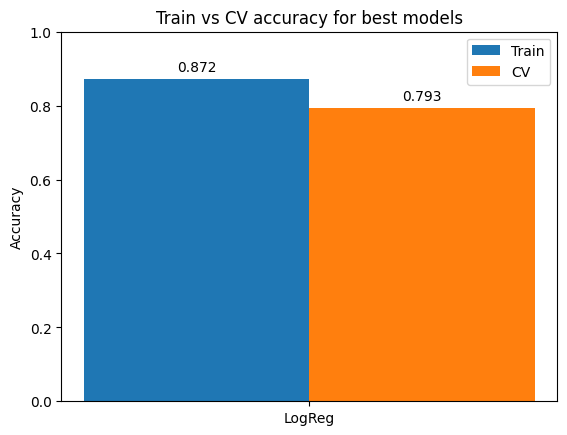

In [17]:
import matplotlib.pyplot as plt
import numpy as np

best_each = (results_df.sort_values('cv', ascending=False)
                       .groupby('model').head(1)
                       .sort_values('model'))

x = np.arange(len(best_each))
width = 0.35

plt.bar(x - width/2, best_each['train'], width, label='Train')
plt.bar(x + width/2, best_each['cv'], width, label='CV')

plt.xticks(x, best_each['model'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Train vs CV accuracy for best models')
plt.legend()

# 막대 위에 점수 텍스트 표시
for i, v in enumerate(best_each['train'].values):
    plt.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center')

for i, v in enumerate(best_each['cv'].values):
    plt.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center')

plt.show()

In [18]:
#결과 저장할 때 사용했던 모델 이름 확인.
results_df['model'].unique()

<StringArray>
['LogReg']
Length: 1, dtype: str

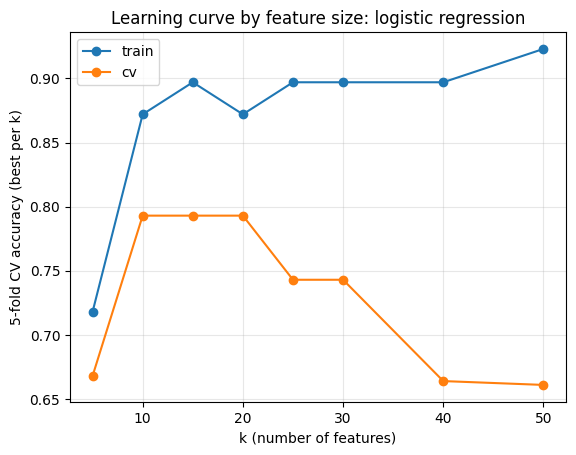

In [19]:
# 모델 × k 조합에서 최고 CV만 골라 곡선 데이터 만들기 (각 점 = 그 k에서의 최고 param)

df_lr = results_df[results_df['model']=='LogReg']

plt.plot(df_lr['k'], df_lr['train'], marker='o', label='train')
plt.plot(df_lr['k'], df_lr['cv'], marker='o', label='cv')

plt.xlabel('k (number of features)')
plt.ylabel('5-fold CV accuracy (best per k)')
plt.title('Learning curve by feature size: logistic regression')
plt.legend(loc=0)
plt.grid(alpha=0.3)
plt.show()

In [20]:
# MlP은 인공신경망 모델이라 해서, 멀티 레이어 즉 여러 층으로 이루어진 작은 딥러닝 모델임. 
# 여기서 히든 노드는 중간층의 뉴런 개수라서 이 히든 노드가 많아질수록 모델이 더 복잡해짐.

# SVM은 서포트 벡터 머신이라 해서 데이터를 나누는 경계선을 찾는 분류 모델임. 
# 여기서 C값은 규제 강도 조절값임. 이게 작으면 단순한 모델이고, 이게 크면 훈련 데이터에 더 빡세게 맞추는 모델이 됨.

# 먼저 잘 저장되어있는지 확인하기
results_df.head()

,model,k,param,train,cv
0,LogReg,5,-,0.718,0.668
1,LogReg,10,-,0.872,0.793
2,LogReg,15,-,0.897,0.793
3,LogReg,20,-,0.872,0.793
4,LogReg,25,-,0.897,0.743


In [21]:
results_df.columns

Index(['model', 'k', 'param', 'train', 'cv'], dtype='str')

In [22]:
results_df['model'].unique()

<StringArray>
['LogReg']
Length: 1, dtype: str

In [23]:
results_df[results_df['model'].isin(['MLP', 'SVM'])].head()

,model,k,param,train,cv


In [24]:
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np
import pandas as pd

In [25]:
results = []

for k in [5, 10, 15, 20, 25, 30]:
    X_k = X.iloc[:, :k]

    for h in [5, 10, 20, 50, 100]:
        model = make_pipeline(
            StandardScaler(),
            MLPClassifier(hidden_layer_sizes=(h,), max_iter=1000, random_state=0)
        )
        train = model.fit(X_k, y).score(X_k, y)
        cv = cross_val_score(model, X_k, y, cv=5).mean()
        results.append(['MLP', k, h, train, cv])

    for c in [0.01, 0.1, 1, 10, 100]:
        model = make_pipeline(
            StandardScaler(),
            SVC(C=c)
        )
        train = model.fit(X_k, y).score(X_k, y)
        cv = cross_val_score(model, X_k, y, cv=5).mean()
        results.append(['SVM', k, c, train, cv])

results_df2 = pd.DataFrame(results, columns=['model', 'k', 'param', 'train', 'cv'])

In [26]:
results_df = pd.concat([results_df, results_df2], ignore_index=True)

In [27]:
results_df['model'].unique()

<StringArray>
['LogReg', 'MLP', 'SVM']
Length: 3, dtype: str

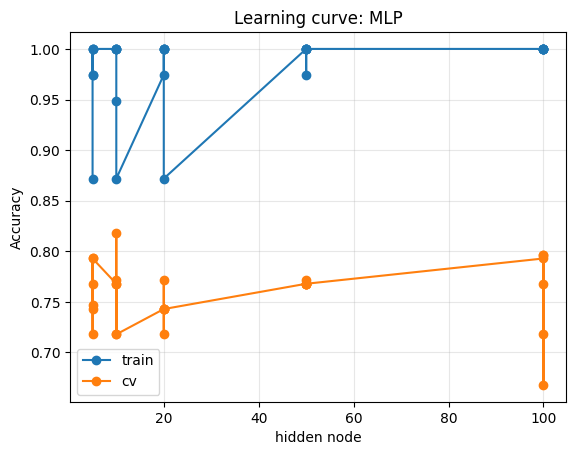

In [28]:
df_mlp = results_df[results_df['model'] == 'MLP'].sort_values('param')

plt.plot(df_mlp['param'], df_mlp['train'], marker='o', label='train')
plt.plot(df_mlp['param'], df_mlp['cv'], marker='o', label='cv')

plt.xlabel('hidden node')
plt.ylabel('Accuracy')
plt.title('Learning curve: MLP')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

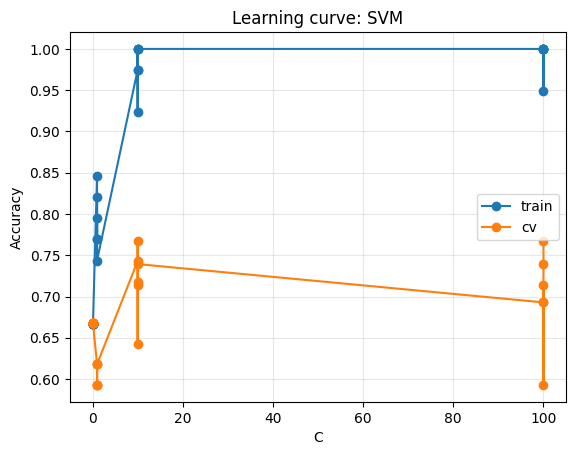

In [29]:
df_svm = results_df[results_df['model'] == 'SVM'].sort_values('param')

plt.plot(df_svm['param'], df_svm['train'], marker='o', label='train')
plt.plot(df_svm['param'], df_svm['cv'], marker='o', label='cv')

plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Learning curve: SVM')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

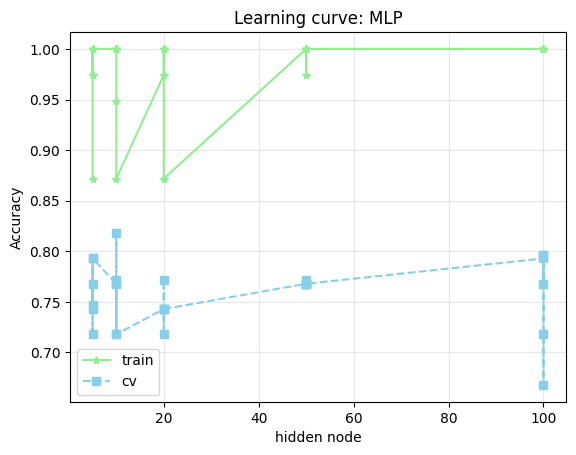

In [30]:
df_mlp = results_df[results_df['model'] == 'MLP'].sort_values('param')

plt.plot(df_mlp['param'], df_mlp['train'],
         marker='*', color='lightgreen', linestyle='-', label='train')

plt.plot(df_mlp['param'], df_mlp['cv'],
         marker='s', color='skyblue', linestyle='--', label='cv')

plt.xlabel('hidden node')
plt.ylabel('Accuracy')
plt.title('Learning curve: MLP')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

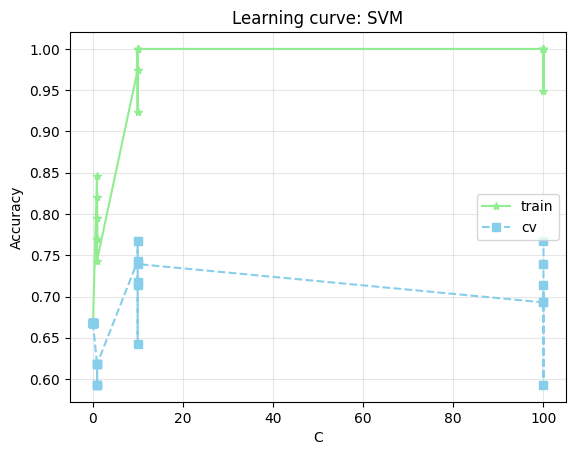

In [31]:
df_svm = results_df[results_df['model'] == 'SVM'].sort_values('param')

plt.plot(df_svm['param'], df_svm['train'],
         marker='*', color='lightgreen', linestyle='-', label='train')

plt.plot(df_svm['param'], df_svm['cv'],
         marker='s', color='skyblue', linestyle='--', label='cv')

plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Learning curve: SVM')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv('experiment_results.csv')

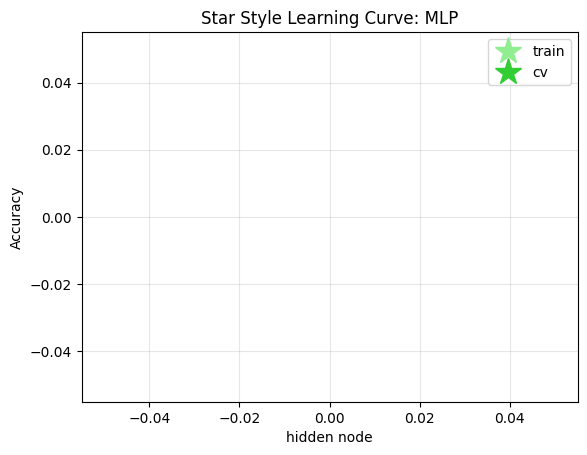

In [3]:
df_mlp = results_df[results_df['model'] == 'MLP'].sort_values('param')

plt.plot(
    df_mlp['param'],
    df_mlp['train'],
    marker='*',
    markersize=20,
    color='lightgreen',
    linestyle='None',
    label='train'
)

plt.plot(
    df_mlp['param'],
    df_mlp['cv'],
    marker='*',
    markersize=20,
    color='limegreen',
    linestyle='None',
    label='cv'
)

# 별들 연결 느낌 추가
plt.plot(
    df_mlp['param'],
    df_mlp['train'],
    color='lightgreen',
    alpha=0.3
)

plt.plot(
    df_mlp['param'],
    df_mlp['cv'],
    color='limegreen',
    alpha=0.3
)

plt.xlabel('hidden node')
plt.ylabel('Accuracy')

plt.title('Star Style Learning Curve: MLP')

plt.legend()

plt.grid(alpha=0.3)

plt.show()